# Capítulo 16 — Métricas para regresión

En el Cuaderno 15 entrenamos regresiones lineales, obtuvimos predicciones y analizamos residuos individuales. Ahora responderemos una pregunta que había quedado abierta: **¿cómo podemos resumir cuánto se equivoca un modelo sobre un conjunto de datos?**

Estudiaremos MAE, MSE, RMSE y \(R^2\). Cada métrica observa los errores desde una perspectiva diferente. Por eso no nos limitaremos a calcular números: los interpretaremos en contexto, los compararemos con una referencia simple y revisaremos qué información puede ocultar cada resumen.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- calcular errores con signo y errores absolutos;
- reconstruir manualmente MAE, MSE y RMSE;
- interpretar MAE y RMSE en las unidades de la variable objetivo;
- comprender por qué MSE penaliza especialmente los errores grandes;
- interpretar \(R^2\) en relación con una predicción basada en el promedio;
- reconocer que \(R^2\) puede ser negativo;
- evaluar modelos mediante funciones de `scikit-learn`;
- comparar una referencia, una regresión simple y una regresión múltiple sobre los mismos datos;
- explicar por qué una única métrica no describe todo el comportamiento del modelo.

La validación cruzada y la selección sistemática de modelos se desarrollarán más adelante.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para los cálculos, Matplotlib para las visualizaciones y `scikit-learn` para entrenar los modelos y comprobar las métricas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split


## 2. Comenzar con cuatro predicciones

Antes de evaluar un modelo real, trabajaremos con el ejemplo de ventas del capítulo teórico. Para cada día calcularemos:

```text
error = valor real - valor predicho

error absoluto = |valor real - valor predicho|
```

Un error positivo indica una subestimación; uno negativo, una sobreestimación.


In [2]:
ventas_reales = np.array([100, 120, 80, 90])
ventas_predichas = np.array([95, 130, 70, 100])

errores = ventas_reales - ventas_predichas
errores_absolutos = np.abs(errores)

ejemplo_ventas = pd.DataFrame({
    "dia": [1, 2, 3, 4],
    "ventas_reales": ventas_reales,
    "ventas_predichas": ventas_predichas,
    "error": errores,
    "error_absoluto": errores_absolutos,
    "direccion": np.where(
        errores > 0,
        "Subestimó",
        np.where(errores < 0, "Sobreestimó", "Acertó"),
    ),
})

ejemplo_ventas


,dia,ventas_reales,ventas_predichas,error,error_absoluto,direccion
0,1,100,95,5,5,Subestimó
1,2,120,130,-10,10,Sobreestimó
2,3,80,70,10,10,Subestimó
3,4,90,100,-10,10,Sobreestimó


Los errores con signo conservan la dirección. Los errores absolutos conservan únicamente la magnitud.

Esto evita que una sobreestimación y una subestimación del mismo tamaño se cancelen entre sí.


In [3]:
pd.DataFrame({
    "resumen": [
        "Suma de errores con signo",
        "Suma de errores absolutos",
    ],
    "resultado": [
        errores.sum(),
        errores_absolutos.sum(),
    ],
})


,resumen,resultado
0,Suma de errores con signo,-5
1,Suma de errores absolutos,35


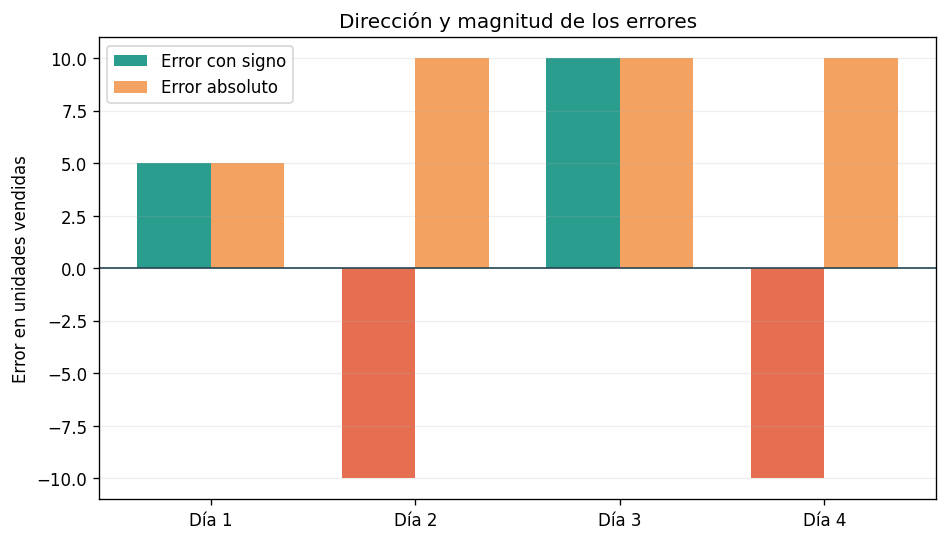

In [4]:
x = np.arange(len(ejemplo_ventas))
ancho = 0.36

plt.figure(figsize=(9, 5))
plt.bar(
    x - ancho / 2,
    errores,
    width=ancho,
    color=np.where(errores >= 0, "#2A9D8F", "#E76F51"),
    label="Error con signo",
)
plt.bar(
    x + ancho / 2,
    errores_absolutos,
    width=ancho,
    color="#F4A261",
    label="Error absoluto",
)
plt.axhline(0, color="#264653", linewidth=1)
plt.xticks(x, [f"Día {dia}" for dia in ejemplo_ventas["dia"]])
plt.ylabel("Error en unidades vendidas")
plt.title("Dirección y magnitud de los errores")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()


El gráfico muestra que los errores con signo pueden quedar por encima o por debajo de cero. En cambio, todos los errores absolutos son positivos: indican cuánto se alejó cada predicción de la venta real.


## 3. Calcular MAE

El **MAE** —error absoluto medio— es el promedio de los errores absolutos:

```text
MAE = suma de errores absolutos / cantidad de casos
```

Su principal ventaja es que conserva las unidades de la variable objetivo.


In [5]:
mae_manual = errores_absolutos.sum() / len(errores_absolutos)
mae_sklearn = mean_absolute_error(
    ventas_reales,
    ventas_predichas,
)

pd.DataFrame({
    "procedimiento": [
        "Cálculo manual",
        "mean_absolute_error()",
    ],
    "MAE": [
        mae_manual,
        mae_sklearn,
    ],
})


,procedimiento,MAE
0,Cálculo manual,8.75
1,mean_absolute_error(),8.75


El MAE es **8,75 unidades vendidas**. Esto significa que, en promedio, las predicciones se alejaron 8,75 unidades de los valores reales.

No significa que todos los errores hayan sido exactamente 8,75. El MAE resume varios casos mediante un promedio y tampoco indica si el modelo tendió a sobreestimar o subestimar.


## 4. Calcular MSE

El **MSE** —error cuadrático medio— eleva cada error al cuadrado y después calcula el promedio:

```text
MSE = promedio de los errores²
```

Al elevar al cuadrado, los errores grandes aumentan mucho más que los pequeños.


In [6]:
errores_cuadrados = errores ** 2
mse_manual = errores_cuadrados.mean()
mse_sklearn = mean_squared_error(
    ventas_reales,
    ventas_predichas,
)

tabla_mse = ejemplo_ventas[[
    "dia",
    "error",
]].copy()
tabla_mse["error_cuadrado"] = errores_cuadrados
tabla_mse


,dia,error,error_cuadrado
0,1,5,25
1,2,-10,100
2,3,10,100
3,4,-10,100


In [7]:
pd.DataFrame({
    "procedimiento": [
        "Cálculo manual",
        "mean_squared_error()",
    ],
    "MSE": [
        mse_manual,
        mse_sklearn,
    ],
})


,procedimiento,MSE
0,Cálculo manual,81.25
1,mean_squared_error(),81.25


El MSE es 81,25. A diferencia del MAE, queda expresado en **unidades vendidas al cuadrado**, por lo que resulta menos intuitivo para comunicar.

Su utilidad está en la penalización cuadrática: un error de 20 aporta cuatro veces más al MSE que un error de 10, no solamente el doble.


## 5. Calcular RMSE

El **RMSE** es la raíz cuadrada del MSE:

```text
RMSE = √MSE
```

La raíz devuelve la métrica a las unidades originales, pero conserva la mayor sensibilidad a los errores grandes.


In [8]:
rmse_manual = np.sqrt(mse_manual)
rmse_sklearn = np.sqrt(
    mean_squared_error(
        ventas_reales,
        ventas_predichas,
    )
)

pd.DataFrame({
    "procedimiento": [
        "Raíz del MSE manual",
        "Cálculo con scikit-learn y NumPy",
    ],
    "RMSE": [
        rmse_manual,
        rmse_sklearn,
    ],
}).round(4)


,procedimiento,RMSE
0,Raíz del MSE manual,9.0139
1,Cálculo con scikit-learn y NumPy,9.0139


El RMSE es aproximadamente **9,01 unidades vendidas**. Podemos interpretarlo en la misma unidad que las ventas, pero no como un simple promedio de errores absolutos.

En este ejemplo, RMSE es mayor que MAE porque el cálculo cuadrático otorga más peso a los errores de mayor magnitud.


## 6. Mismo MAE, errores diferentes

Una métrica promedio puede ocultar la distribución de los errores. Construiremos dos sistemas con el mismo MAE:

- el Sistema A se equivoca por 10 en todos los casos;
- el Sistema B acierta tres casos y se equivoca por 40 en uno.


In [9]:
errores_a = np.array([10, 10, 10, 10])
errores_b = np.array([0, 0, 0, 40])

comparacion_patrones = pd.DataFrame({
    "sistema": ["A", "B"],
    "MAE": [
        errores_a.mean(),
        errores_b.mean(),
    ],
    "MSE": [
        np.mean(errores_a ** 2),
        np.mean(errores_b ** 2),
    ],
    "RMSE": [
        np.sqrt(np.mean(errores_a ** 2)),
        np.sqrt(np.mean(errores_b ** 2)),
    ],
})

comparacion_patrones


,sistema,MAE,MSE,RMSE
0,A,10.0,100.0,10.0
1,B,10.0,400.0,20.0


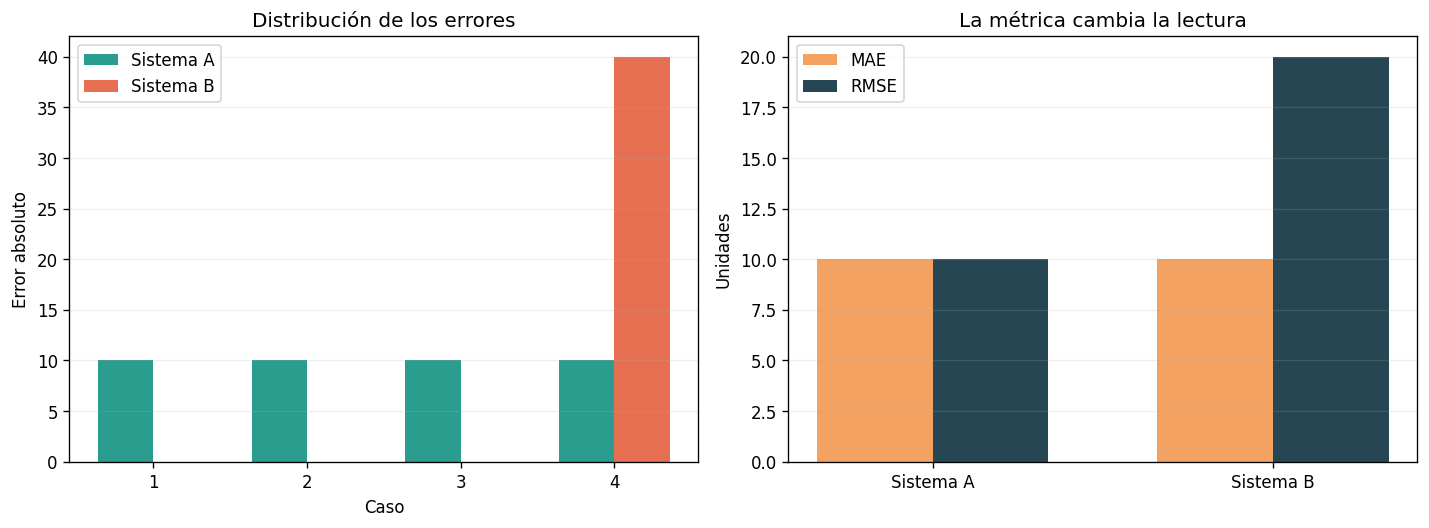

In [10]:
x = np.arange(1, 5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    x - 0.18,
    errores_a,
    width=0.36,
    color="#2A9D8F",
    label="Sistema A",
)
axes[0].bar(
    x + 0.18,
    errores_b,
    width=0.36,
    color="#E76F51",
    label="Sistema B",
)
axes[0].set_xticks(x)
axes[0].set_xlabel("Caso")
axes[0].set_ylabel("Error absoluto")
axes[0].set_title("Distribución de los errores")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

ancho = 0.34
posiciones = np.arange(2)
axes[1].bar(
    posiciones - ancho / 2,
    comparacion_patrones["MAE"],
    width=ancho,
    color="#F4A261",
    label="MAE",
)
axes[1].bar(
    posiciones + ancho / 2,
    comparacion_patrones["RMSE"],
    width=ancho,
    color="#264653",
    label="RMSE",
)
axes[1].set_xticks(posiciones)
axes[1].set_xticklabels(["Sistema A", "Sistema B"])
axes[1].set_ylabel("Unidades")
axes[1].set_title("La métrica cambia la lectura")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


MAE considera equivalentes ambos sistemas porque el error absoluto promedio es 10. RMSE prefiere el Sistema A, ya que el error aislado de 40 del Sistema B recibe una penalización mayor.

Ninguna lectura es universalmente correcta. Si un error de 40 resulta especialmente grave, RMSE aporta una advertencia importante. Si los costos crecen de manera aproximadamente proporcional, MAE puede representar mejor el problema.


## 7. Comprender \(R^2\)

\(R^2\) responde una pregunta diferente:

> ¿Cuánto mejora el modelo respecto de una referencia que predice siempre el promedio?

Para calcularlo comparamos dos sumas:

```text
SS_res = suma de los errores² del modelo

SS_tot = suma de las diferencias² respecto del promedio real

R² = 1 - SS_res / SS_tot
```


In [11]:
promedio_real = ventas_reales.mean()
ss_res = np.sum(
    (ventas_reales - ventas_predichas) ** 2
)
ss_tot = np.sum(
    (ventas_reales - promedio_real) ** 2
)
r2_manual = 1 - ss_res / ss_tot
r2_sklearn = r2_score(
    ventas_reales,
    ventas_predichas,
)

pd.DataFrame({
    "componente": [
        "Promedio de las ventas reales",
        "SS_res: errores² del sistema",
        "SS_tot: errores² de la referencia",
        "R² manual",
        "R² con r2_score()",
    ],
    "valor": [
        promedio_real,
        ss_res,
        ss_tot,
        r2_manual,
        r2_sklearn,
    ],
}).round(4)


,componente,valor
0,Promedio de las ventas reales,97.5000
1,SS_res: errores² del sistema,325.0000
2,SS_tot: errores² de la referencia,875.0000
3,R² manual,0.6286
4,R² con r2_score(),0.6286


Un \(R^2\) igual a 1 representa predicciones perfectas. Un valor cercano a 0 indica un desempeño parecido al de predecir el promedio. Un valor negativo significa que el modelo funciona peor que esa referencia.

\(R^2\) no expresa el error en unidades vendidas. Por eso debe complementarse con MAE o RMSE.


In [12]:
prediccion_muy_mala = np.array([150, 150, 150, 150])

pd.DataFrame({
    "sistema": [
        "Predicciones originales",
        "Predicción deliberadamente mala",
    ],
    "R²": [
        r2_score(ventas_reales, ventas_predichas),
        r2_score(ventas_reales, prediccion_muy_mala),
    ],
})


,sistema,R²
0,Predicciones originales,0.628571
1,Predicción deliberadamente mala,-12.600000


La segunda regla obtiene un \(R^2\) negativo. El cálculo es válido: advierte que sus predicciones son peores que una referencia muy simple.


## 8. Recuperar el problema de viviendas

Continuaremos con el mismo dataset didáctico del Cuaderno 15. Volvemos a generarlo con la misma semilla para que el cuaderno sea independiente y reproducible.

Los precios son ficticios y no representan tasaciones ni valores reales de mercado.


In [13]:
rng = np.random.default_rng(15)
n_viviendas = 48

superficie = rng.integers(45, 151, size=n_viviendas)
ambientes_estimados = np.rint(superficie / 25).astype(int)
ambientes = np.clip(
    ambientes_estimados + rng.integers(-1, 2, size=n_viviendas),
    1,
    6,
)
antiguedad = rng.integers(0, 51, size=n_viviendas)
distancia = np.round(rng.uniform(1, 15, size=n_viviendas), 1)
barrio = rng.choice(
    ["Centro", "Norte", "Oeste", "Sur"],
    size=n_viviendas,
)

efecto_barrio = pd.Series(barrio).map({
    "Centro": 18000,
    "Norte": 12000,
    "Oeste": 3000,
    "Sur": -4000,
}).to_numpy()

precio = (
    25000
    + 1050 * superficie
    + 6500 * ambientes
    - 550 * antiguedad
    - 2200 * distancia
    + efecto_barrio
    + rng.normal(0, 7000, size=n_viviendas)
)

viviendas = pd.DataFrame({
    "id_vivienda": [f"V{i:03d}" for i in range(1, n_viviendas + 1)],
    "superficie_m2": superficie,
    "ambientes": ambientes,
    "antiguedad_anios": antiguedad,
    "distancia_centro_km": distancia,
    "barrio": barrio,
    "precio_usd": np.round(precio / 500) * 500,
})

viviendas.head()


,id_vivienda,superficie_m2,ambientes,antiguedad_anios,distancia_centro_km,barrio,precio_usd
0,V001,143,6,47,3.9,Centro,210500.0
1,V002,118,6,21,6.7,Oeste,154000.0
2,V003,119,6,2,4.7,Norte,184500.0
3,V004,131,6,49,3.8,Oeste,172000.0
4,V005,70,4,47,4.7,Norte,105000.0


## 9. Separar los mismos casos de entrenamiento y prueba

Usaremos la misma división del Cuaderno 15. Compararemos tres estrategias:

1. una referencia que predice siempre el promedio de `y_train`;
2. una regresión lineal simple que usa solo la superficie;
3. una regresión lineal múltiple con cuatro variables numéricas.

Todos los modelos serán evaluados sobre exactamente las mismas viviendas de prueba.


In [14]:
X_simple = viviendas[["superficie_m2"]]
y = viviendas["precio_usd"]

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.25,
    random_state=15,
)

variables_multiples = [
    "superficie_m2",
    "ambientes",
    "antiguedad_anios",
    "distancia_centro_km",
]
X_multiple = viviendas[variables_multiples]
X_train_m = X_multiple.loc[X_train_s.index]
X_test_m = X_multiple.loc[X_test_s.index]

pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba"],
    "filas": [len(X_train_s), len(X_test_s)],
})


,conjunto,filas
0,Entrenamiento,36
1,Prueba,12


## 10. Entrenar los modelos y la referencia

`DummyRegressor(strategy="mean")` aprende el promedio de `y_train` y lo usa para todos los casos. No intenta aprovechar las variables predictoras: funciona como una línea de base.


In [15]:
referencia = DummyRegressor(strategy="mean")
referencia.fit(X_train_s, y_train)

modelo_simple = LinearRegression()
modelo_simple.fit(X_train_s, y_train)

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train_m, y_train)

pred_referencia = referencia.predict(X_test_s)
pred_simple = modelo_simple.predict(X_test_s)
pred_multiple = modelo_multiple.predict(X_test_m)

print(
    "Predicción constante de la referencia: "
    f"USD {pred_referencia[0]:,.2f}"
)


Predicción constante de la referencia: USD 132,250.00


## 11. Crear una función de evaluación

Para evitar repetir cálculos, construiremos una función que reciba los valores reales y predichos y devuelva las cuatro métricas.


In [16]:
def evaluar_regresion(nombre, valores_reales, valores_predichos):
    mse = mean_squared_error(
        valores_reales,
        valores_predichos,
    )
    return {
        "modelo": nombre,
        "MAE": mean_absolute_error(
            valores_reales,
            valores_predichos,
        ),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(
            valores_reales,
            valores_predichos,
        ),
    }


metricas = pd.DataFrame([
    evaluar_regresion(
        "Referencia: promedio",
        y_test,
        pred_referencia,
    ),
    evaluar_regresion(
        "Regresión simple",
        y_test,
        pred_simple,
    ),
    evaluar_regresion(
        "Regresión múltiple",
        y_test,
        pred_multiple,
    ),
]).set_index("modelo")

metricas.round(3)


,MAE,MSE,RMSE,R²
modelo,,,,
Referencia: promedio,33250.000,1.481688e+09,38492.694,-0.005
Regresión simple,12927.735,2.376587e+08,15416.184,0.839
Regresión múltiple,10835.037,1.701899e+08,13045.685,0.885


Las tres filas se calculan sobre el mismo `y_test`, por lo que la comparación es justa dentro de esta división.

- MAE y RMSE menores indican errores más pequeños.
- \(R^2\) mayor indica una mejora más clara respecto de la referencia basada en el promedio.
- MSE conserva la penalización cuadrática, pero sus unidades al cuadrado dificultan la comunicación.

La referencia puede obtener un \(R^2\) levemente negativo. `DummyRegressor` predice el promedio **del entrenamiento**, mientras que la definición matemática de \(R^2\) usa como comparación el promedio **del conjunto evaluado**. Como ambos promedios no tienen por qué coincidir, la línea de base práctica puede quedar un poco por debajo de cero.


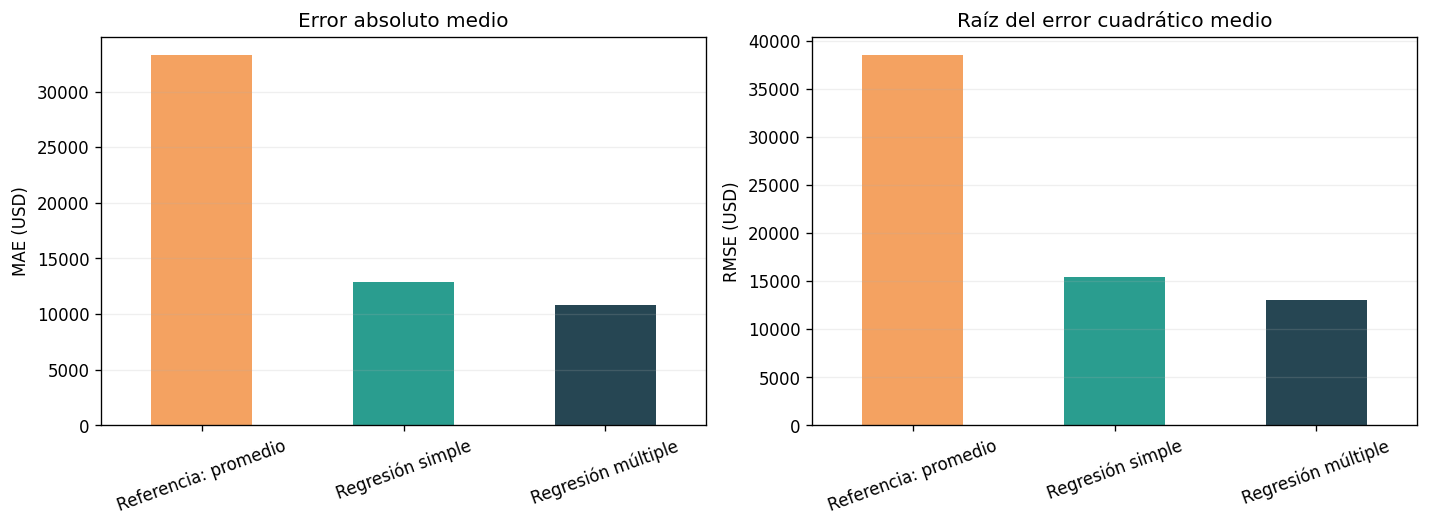

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colores = ["#F4A261", "#2A9D8F", "#264653"]

metricas["MAE"].plot(
    kind="bar",
    ax=axes[0],
    color=colores,
)
axes[0].set_title("Error absoluto medio")
axes[0].set_ylabel("MAE (USD)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.2)

metricas["RMSE"].plot(
    kind="bar",
    ax=axes[1],
    color=colores,
)
axes[1].set_title("Raíz del error cuadrático medio")
axes[1].set_ylabel("RMSE (USD)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


MAE y RMSE se expresan en dólares y pueden comunicarse de forma directa. En este conjunto de prueba, la regresión múltiple aprovecha más información y reduce ambos errores frente a la regresión simple y la referencia.

Esta conclusión es ilustrativa y corresponde a una única separación de datos. Una diferencia pequeña no debería presentarse como una superioridad definitiva sin estudiar su estabilidad.


## 12. Comparar valores reales y predichos

Un gráfico permite complementar las métricas. La diagonal representa predicciones perfectas: cuanto más cerca queda un punto de esa línea, menor es su error.


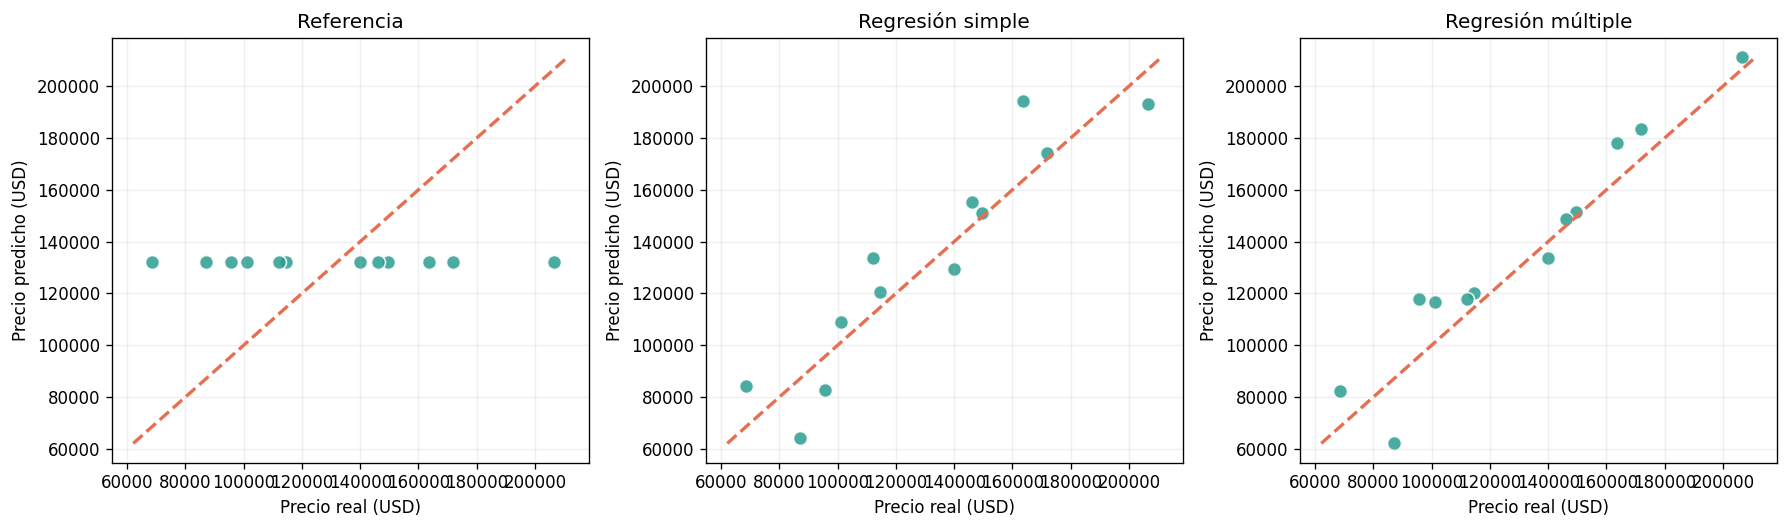

In [18]:
predicciones_modelos = {
    "Referencia": pred_referencia,
    "Regresión simple": pred_simple,
    "Regresión múltiple": pred_multiple,
}

limite_min = min(
    y_test.min(),
    pred_referencia.min(),
    pred_simple.min(),
    pred_multiple.min(),
)
limite_max = max(
    y_test.max(),
    pred_referencia.max(),
    pred_simple.max(),
    pred_multiple.max(),
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nombre, predicciones) in zip(
    axes,
    predicciones_modelos.items(),
):
    ax.scatter(
        y_test,
        predicciones,
        color="#2A9D8F",
        s=70,
        alpha=0.85,
        edgecolor="white",
    )
    ax.plot(
        [limite_min, limite_max],
        [limite_min, limite_max],
        color="#E76F51",
        linestyle="--",
        linewidth=2,
    )
    ax.set_xlabel("Precio real (USD)")
    ax.set_ylabel("Precio predicho (USD)")
    ax.set_title(nombre)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


La referencia produce una línea horizontal porque asigna la misma predicción a todas las viviendas. Los modelos lineales generan estimaciones diferentes según sus variables.

La regresión múltiple se aproxima mejor a la diagonal en varios casos, pero todavía comete errores. Las métricas resumen esas distancias; el gráfico permite observar dónde ocurren.


## 13. Revisar los residuos

Calcularemos los residuos de los dos modelos entrenados:

```text
residuo = valor real - valor predicho
```

Un residuo positivo indica que el modelo subestimó; uno negativo, que sobreestimó.


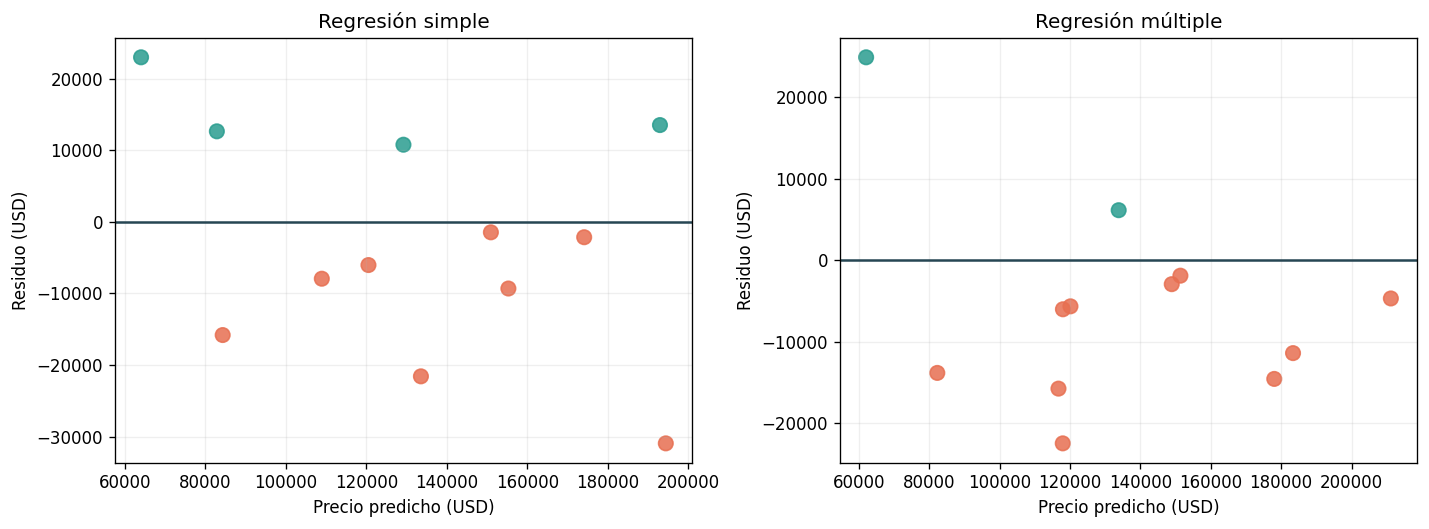

In [19]:
residuos_simple = y_test.to_numpy() - pred_simple
residuos_multiple = y_test.to_numpy() - pred_multiple

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, predicciones, residuos, titulo in [
    (
        axes[0],
        pred_simple,
        residuos_simple,
        "Regresión simple",
    ),
    (
        axes[1],
        pred_multiple,
        residuos_multiple,
        "Regresión múltiple",
    ),
]:
    ax.axhline(0, color="#264653", linewidth=1.5)
    ax.scatter(
        predicciones,
        residuos,
        c=np.where(
            residuos >= 0,
            "#2A9D8F",
            "#E76F51",
        ),
        s=75,
        alpha=0.85,
    )
    ax.set_xlabel("Precio predicho (USD)")
    ax.set_ylabel("Residuo (USD)")
    ax.set_title(titulo)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


Las métricas no muestran la dirección de los errores ni revelan por sí solas si se concentran en ciertos rangos. El gráfico de residuos conserva esa información.

Con solo doce viviendas de prueba no conviene diagnosticar patrones definitivos. Aun así, la visualización recuerda que **las métricas resumen y el análisis de errores explica**.


## 14. Inspeccionar los casos individuales

Ordenaremos las viviendas según el error absoluto de la regresión múltiple. Así podremos identificar qué casos influyen más en MAE y, especialmente, en RMSE.


In [20]:
resultados_prueba = X_test_m.copy()
resultados_prueba["precio_real"] = y_test
resultados_prueba["precio_predicho"] = pred_multiple
resultados_prueba["residuo"] = (
    resultados_prueba["precio_real"]
    - resultados_prueba["precio_predicho"]
)
resultados_prueba["error_absoluto"] = np.abs(
    resultados_prueba["residuo"]
)
resultados_prueba["error_cuadrado"] = (
    resultados_prueba["residuo"] ** 2
)

resultados_prueba.sort_values(
    "error_absoluto",
    ascending=False,
).round(2)


,superficie_m2,ambientes,antiguedad_anios,distancia_centro_km,precio_real,precio_predicho,residuo,error_absoluto,error_cuadrado
22,55,2,2,13.1,87000.0,62077.47,24922.53,24922.53,6.211323e+08
36,68,4,23,1.3,95500.0,117941.64,-22441.64,22441.64,5.036272e+08
33,86,3,13,7.4,101000.0,116725.78,-15725.78,15725.78,2.473003e+08
39,145,5,35,10.4,163500.0,178034.98,-14534.98,14534.98,2.112657e+08
35,69,3,19,11.4,68500.0,82298.57,-13798.57,13798.57,1.904006e+08
3,131,6,49,3.8,172000.0,183368.94,-11368.94,11368.94,1.292528e+08
26,100,3,7,7.9,140000.0,133835.35,6164.65,6164.65,3.800290e+07
25,103,3,41,8.8,112000.0,117990.79,-5990.79,5990.79,3.588955e+07
14,94,3,6,10.3,114500.0,120129.91,-5629.91,5629.91,3.169592e+07
30,144,6,16,4.7,206500.0,211163.63,-4663.63,4663.63,2.174948e+07


Los primeros casos de la tabla aportan más al MAE por su mayor error absoluto. Su influencia sobre MSE y RMSE aumenta todavía más porque el residuo se eleva al cuadrado.

En un proyecto real, correspondería investigar estos casos: podrían ser valores legítimos difíciles de predecir, datos erróneos o ejemplos de una relación que el modelo lineal no representa bien. No deben eliminarse automáticamente.


## 15. Elegir e interpretar métricas

Podemos asociar cada métrica con una pregunta:

| Métrica | Pregunta principal | Unidad |
|---|---|---|
| MAE | ¿Cuánto se equivoca el modelo en promedio? | Unidad original |
| MSE | ¿Qué tan grandes son los errores al cuadrado? | Unidad al cuadrado |
| RMSE | ¿Cuánto se equivoca, dando más peso a errores grandes? | Unidad original |
| \(R^2\) | ¿Cuánto mejora frente a predecir el promedio? | Sin unidad |

Ninguna métrica es suficiente por sí sola. La elección depende de la escala del objetivo, el costo de los errores y el uso de las predicciones.


### Una comparación prudente

Para comparar modelos correctamente:

- usamos el mismo problema y la misma variable objetivo;
- reservamos los mismos casos de prueba;
- calculamos las mismas métricas;
- incluimos una referencia simple;
- revisamos errores individuales y no solo promedios;
- consideramos si la mejora tiene importancia práctica;
- recordamos que una única división train/test no demuestra estabilidad.

Un modelo más complejo no es automáticamente mejor. Si la mejora es pequeña, también deben considerarse la simplicidad, la interpretabilidad y el costo de mantenimiento.


## 16. Actividad breve

Modificá `ultima_prediccion` y ejecutá la celda. Observarás cómo cambia cada métrica cuando una de las cuatro predicciones se acerca o se aleja del valor real.


In [21]:
ultima_prediccion = 100

reales_actividad = np.array([100, 120, 80, 90])
pred_actividad = np.array([
    95,
    130,
    70,
    ultima_prediccion,
])

mse_actividad = mean_squared_error(
    reales_actividad,
    pred_actividad,
)

pd.DataFrame({
    "MAE": [
        mean_absolute_error(
            reales_actividad,
            pred_actividad,
        )
    ],
    "MSE": [mse_actividad],
    "RMSE": [np.sqrt(mse_actividad)],
    "R²": [
        r2_score(
            reales_actividad,
            pred_actividad,
        )
    ],
}).round(4)


,MAE,MSE,RMSE,R²
0,8.75,81.25,9.0139,0.6286


Probá, por ejemplo, con `90`, `120`, `150` y `250`.

Luego respondé:

1. ¿Qué valor produce una predicción perfecta para el cuarto caso?
2. ¿Qué métrica aumenta más visiblemente cuando introducís un error extremo?
3. ¿En qué momento \(R^2\) se vuelve negativo?
4. ¿Qué unidad tiene cada resultado?
5. ¿Alcanza esta tabla para saber si el error fue una sobreestimación o una subestimación?


## 17. Síntesis

En este cuaderno:

- distinguimos error con signo y error absoluto;
- calculamos manualmente MAE, MSE y RMSE;
- comprobamos los resultados con `scikit-learn`;
- observamos la penalización cuadrática de los errores grandes;
- demostramos que dos sistemas con el mismo MAE pueden tener distinto RMSE;
- reconstruimos e interpretamos \(R^2\);
- verificamos que \(R^2\) puede ser negativo;
- evaluamos una referencia y dos regresiones sobre los mismos datos;
- interpretamos MAE y RMSE en dólares;
- complementamos las métricas con gráficos y errores individuales.

Evaluar regresión no consiste en buscar un único número ganador. Consiste en elegir métricas coherentes con el problema, compararlas bajo condiciones justas y comprender qué errores resumen y cuáles pueden ocultar.


## Para pensar

1. ¿Por qué la suma de errores con signo puede dar una imagen engañosa del desempeño?
2. ¿Qué diferencia práctica existe entre penalizar un error de forma lineal y elevarlo al cuadrado?
3. ¿Por qué MAE suele ser más fácil de comunicar que MSE?
4. ¿Un \(R^2\) alto garantiza que el error en dólares, grados o minutos sea aceptable?
5. Si un modelo tiene menor MAE pero mayor RMSE que otro, ¿qué podría estar ocurriendo?
6. ¿Por qué todos los modelos deben evaluarse sobre los mismos casos de prueba?
7. ¿Qué información aportan los gráficos de residuos que no aparece en una tabla de métricas?
8. ¿Por qué una diferencia mínima entre dos modelos no debería decidir automáticamente cuál usar?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
